In [681]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [682]:
data_dir = Path("data")
INDIR = Path("data/data_raw")
OUTDIR = Path("data/data_processed")

OUTDIR.mkdir(parents=True, exist_ok=True)

## Tratamento de PARTICIPANTES_2024

In [683]:
arquivo = INDIR / "PARTICIPANTES_2024.csv"
df = pd.read_csv(arquivo, sep=';', encoding='latin-1')

In [684]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

display(df.head())

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023
0,210062064233,2024,5,F,1,1,1,1,3,NaN,0,4314902,Porto Alegre,43,RS,F,F,C,D,4,B,C,A,C,D,C,B,B,A,B,B,B,D,A,B,B,E,A
1,210062064234,2024,11,F,1,1,1,1,10,NaN,0,4318903,São Luiz Gonzaga,43,RS,B,C,A,D,2,B,E,A,B,B,B,B,B,A,A,A,A,B,A,B,A,C,A
2,210062064235,2024,11,F,1,1,1,1,9,NaN,0,4320107,Sarandi,43,RS,H,F,F,D,5,B,J,A,C,D,B,B,C,A,B,B,B,D,B,B,A,D,A
3,210062064236,2024,3,F,1,3,1,2,0,1.0,0,4313409,Novo Hamburgo,43,RS,B,B,B,B,6,A,C,A,B,C,B,A,B,A,B,A,A,A,A,B,A,D,A
4,210062064237,2024,16,M,3,1,1,1,18,NaN,0,4309209,Gravataí,43,RS,B,B,C,C,2,A,A,A,B,C,A,A,B,A,A,A,A,B,A,B,A,B,A


In [685]:
df_participantes = df[['IN_TREINEIRO', 'SG_UF_PROVA', 'Q007', 'NO_MUNICIPIO_PROVA']]

In [686]:
df_participantes.isnull().mean()*100

IN_TREINEIRO          0.0
SG_UF_PROVA           0.0
Q007                  0.0
NO_MUNICIPIO_PROVA    0.0
dtype: float64

In [687]:
df_participantes.info()

<class 'pandas.DataFrame'>
RangeIndex: 4332944 entries, 0 to 4332943
Data columns (total 4 columns):
 #   Column              Dtype
---  ------              -----
 0   IN_TREINEIRO        int64
 1   SG_UF_PROVA         str  
 2   Q007                str  
 3   NO_MUNICIPIO_PROVA  str  
dtypes: int64(1), str(3)
memory usage: 132.2 MB


In [688]:
df_participantes = df_participantes[df_participantes['IN_TREINEIRO'] != 1]
df_participantes = df_participantes.drop(columns=['IN_TREINEIRO'])

In [689]:
cor_renda_map_sm = {
    "A": 0.0,
    "B": 1.0,
    "C": 1.5,
    "D": 2.0,
    "E": 2.5,
    "F": 3.0,
    "G": 4.0,
    "H": 5.0,
    "I": 6.0,
    "J": 7.0,
    "K": 8.0,
    "L": 9.0,
    "M": 10.0,
    "N": 12.0,
    "O": 15.0,
    "P": 20.0,
    "Q": 20.0
}

df_participantes['Q007'] = df_participantes['Q007'].map(cor_renda_map_sm)
df_participantes['Q007'] = df_participantes['Q007'].astype("Float64")
df_participantes = df_participantes.rename(columns={'Q007': 'RENDA_FAMILIAR_SM'})

In [690]:
df_participantes = df_participantes[df_participantes['SG_UF_PROVA'] == 'SP']
df_participantes = df_participantes.drop(columns=['SG_UF_PROVA'])

In [ ]:
df_participantes['NO_MUNICIPIO_PROVA'] = df_participantes['NO_MUNICIPIO_PROVA'].str.upper()

grande_sp = {
    'SÃO PAULO', 'ARUJÁ', 'BARUERI', 'BIRITIBA-MIRIM', 'CAIEIRAS',
    'CAJAMAR', 'CARAPICUÍBA', 'COTIA', 'DIADEMA', 'EMBU DAS ARTES',
    'EMBU-GUAÇU', 'FERRAZ DE VASCONCELOS', 'FRANCISCO MORATO',
    'FRANCO DA ROCHA', 'GUARAREMA', 'GUARULHOS', 'ITAPECERICA DA SERRA',
    'ITAPEVI', 'ITAQUAQUECETUBA', 'JANDIRA', 'JUQUITIBA', 'MAIRIPORÃ',
    'MAUÁ', 'MOGI DAS CRUZES', 'OSASCO', 'PIRAPORA DO BOM JESUS',
    'POÁ', 'RIBEIRÃO PIRES', 'RIO GRANDE DA SERRA', 'SALESÓPOLIS',
    'SANTA ISABEL', 'SANTANA DE PARNAÍBA', 'SANTO ANDRÉ',
    'SÃO BERNARDO DO CAMPO', 'SÃO CAETANO DO SUL', 'SUZANO',
    'TABOÃO DA SERRA', 'VARGEM GRANDE PAULISTA'
}

litoral = {
    'SANTOS', 'SÃO VICENTE', 'PRAIA GRANDE', 'GUARUJÁ',
    'CUBATÃO', 'BERTIOGA', 'MONGAGUÁ', 'ITANHAÉM',
    'PERUÍBE', 'CARAGUATATUBA', 'UBATUBA',
    'SÃO SEBASTIÃO', 'ILHABELA', 'IGUAPE', 'CANANÉIA'
}

def classificar_regiao(cidade):
    if cidade in grande_sp:
        return 'GRANDE_SP'
    elif cidade in litoral:
        return 'LITORAL'
    else:
        return 'INTERIOR'

df_participantes['REGIAO'] = df_participantes['NO_MUNICIPIO_PROVA'].apply(classificar_regiao)

In [692]:
df_participantes.info()

<class 'pandas.DataFrame'>
Index: 524264 entries, 28 to 4332941
Data columns (total 3 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   RENDA_FAMILIAR_SM   524264 non-null  Float64
 1   NO_MUNICIPIO_PROVA  524264 non-null  str    
 2   REGIAO              524264 non-null  str    
dtypes: Float64(1), str(2)
memory usage: 16.5 MB


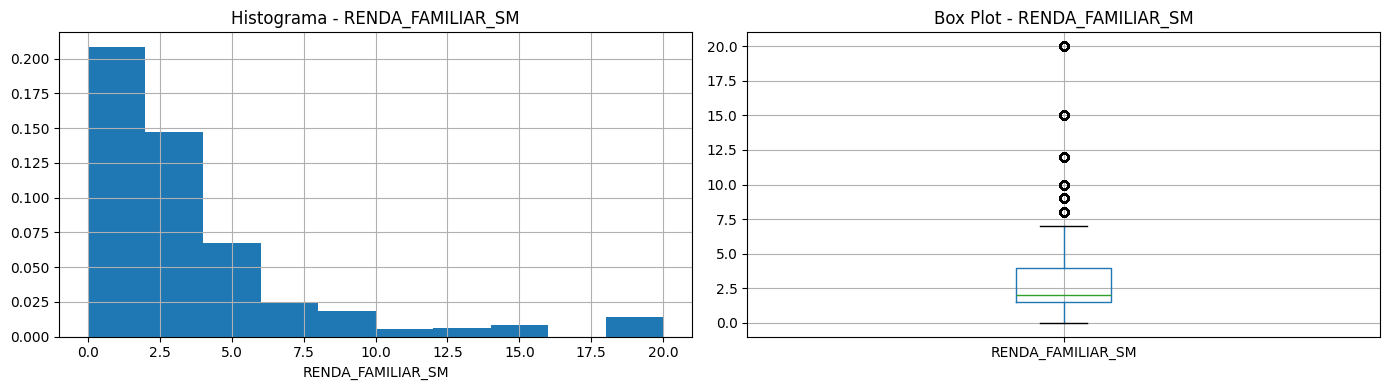

In [693]:
analise_cols = ['RENDA_FAMILIAR_SM']

for col in analise_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    df_participantes[col].hist(ax=ax1, density=True)
    ax1.set_title(f'Histograma - {col}')
    ax1.set_xlabel(col)
    
    df_participantes.boxplot(column=col, ax=ax2)
    ax2.set_title(f'Box Plot - {col}')
    
    plt.tight_layout()
    plt.show()

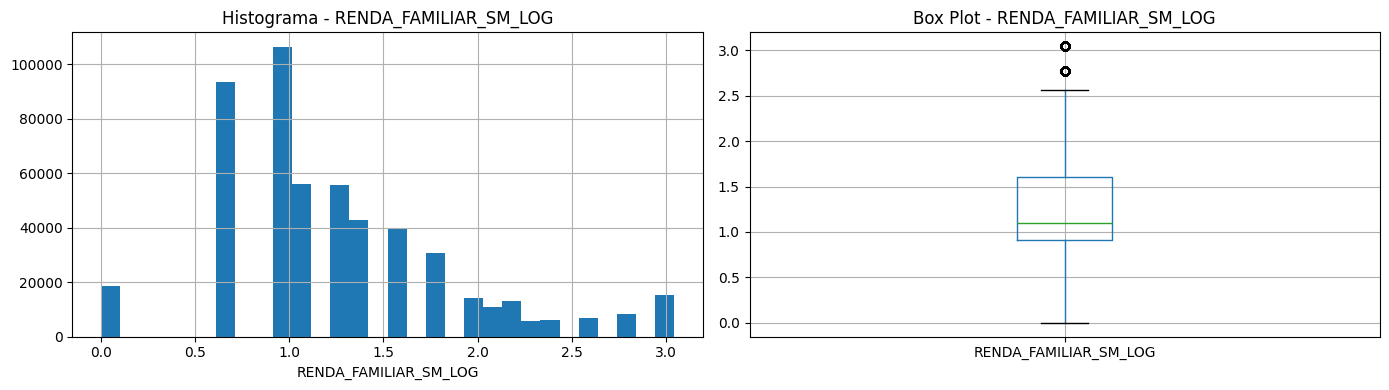

In [694]:
# TRANSFORMAÇÃO PARA ESCALA LOGARÍTMICA DE NET_SALES

df_participantes['RENDA_FAMILIAR_SM_LOG'] = np.log1p(df_participantes['RENDA_FAMILIAR_SM'])

analise_cols = ['RENDA_FAMILIAR_SM_LOG']

for col in analise_cols:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    df_participantes[col].hist(ax=ax1, bins=30)
    ax1.set_title(f'Histograma - {col}')
    ax1.set_xlabel(col)
    
    df_participantes.boxplot(column=col, ax=ax2)
    ax2.set_title(f'Box Plot - {col}')
    
    plt.tight_layout()
    plt.show()

In [695]:
# TRATAMENTO DE OUTLIERS

analise_de_outliers = ['RENDA_FAMILIAR_SM_LOG']
for col in analise_de_outliers:
    Q1 = df_participantes[col].quantile(0.25)
    Q3 = df_participantes[col].quantile(0.75)
    IQR = Q3 - Q1
    df_participantes = df_participantes[(df_participantes[col] >= Q1 - 1.5*IQR) & (df_participantes[col] <= Q3 + 1.5*IQR)]

print(((df_participantes.shape[0] - df_participantes.shape[0]) / df_participantes.shape[0]) * 100)

0.0


In [696]:
df_municipio = df_participantes.groupby('NO_MUNICIPIO_PROVA').agg(
    RENDA_FAMILIAR_SM_LOG_MEDIANA=('RENDA_FAMILIAR_SM_LOG', 'median'),
    RENDA_FAMILIAR_SM_MEDIA=('RENDA_FAMILIAR_SM', 'mean'),
    REGIAO=('REGIAO', 'first')
).reset_index()

In [697]:
df_municipio.head()

,NO_MUNICIPIO_PROVA,RENDA_FAMILIAR_SM_LOG_MEDIANA,RENDA_FAMILIAR_SM_MEDIA,REGIAO
0,ADAMANTINA,1.098612,2.752041,INTERIOR
1,AGUDOS,1.252763,2.883191,INTERIOR
2,AMERICANA,1.386294,3.621081,INTERIOR
3,AMPARO,1.252763,2.927684,INTERIOR
4,ANDRADINA,1.098612,2.593284,INTERIOR


## Tratamento Resultados

In [698]:
arquivo = INDIR / "RESULTADOS_2024.csv"
df = pd.read_csv(arquivo, sep=';', encoding='latin-1')

In [699]:
df.head()

,NU_SEQUENCIAL,NU_ANO,CO_ESCOLA,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
0,206403,2024,23052929.0,2301406.0,Aratuba,23.0,CE,2.0,1.0,1.0,2301406,Aratuba,23,CE,1,1,1,1,1420.0,1383.0,1395.0,1408.0,436.8,377.8,423.4,427.1,CAABADDBBBACACACDEABDBABDDCCBACDCCBAACCABCBAC,BEABBCDABCDBAEEBDDABCCDAADDABACDDAB..........,BCADBCDCEDBDDBDDCDBCBB*BBDEAEEBCDCABBDDAAECEE,CBDCCADBBECCBADEACCBDCACECDDABBDBADBAAEDBCCAB,1,CAEDAACCAEEXCBBAEDBBCAACDEDCBCEECAAEDDDEBBDDB,CECEBEBCDBADDEBBABCDCAECEDADBAEABEADCEDADACBC,CAAAECDDDAECBECEDDCBDEDDCECBDCBCEADBBDBDDCBEDA...,CECEBEDADCAADECDBBCEBDCCCACABBABBADDDCEADBBCE,1.0,80.0,60.0,60.0,80.0,20.0,300.0
1,3604651,2024,42103770.0,4218004.0,Tijucas,42.0,SC,4.0,1.0,1.0,4218004,Tijucas,42,SC,1,1,1,1,1422.0,1384.0,1396.0,1410.0,521.9,601.9,605.5,689.2,EBDEEADAECCAAEDBBEDABACDBCEEDDDEDBDDABDBCCECA,BADBACDAECEDEABBEADDBBDEBEDADEDEEACBBECABCEDA,AACEACADECBCDAEEBEDCBCBEDDCDEAEDEBDABDCECDDDB,DBAEDBECBDDBCCBBABBDECCCCEECBACCDBCDAAABBAAAD,0,BBCEDBBAEXCCAEDDBCAEDAACAAEDDDEBBECBCEEDCAACD,DADABCDCECEDEBBBEBCDBADACBCADCEBEADBAECAECEDA,AACEADDDACDADECBBDBEEBDDECCBEDDCADBBDEBCEBDCEC...,DBCECEACADABBECBEDADCCDCCABBBCECEBCEADABBADDD,1.0,160.0,200.0,200.0,180.0,180.0,920.0
2,1461268,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4122404,Rolândia,41,PR,1,1,1,1,1419.0,1385.0,1398.0,1407.0,363.0,548.4,557.2,456.4,CABAECDBADDCDEACABEACEABEDDCEDCDCCBDBDBDDBDCC,DAEDBCDCEBCCECADDACABDEBDCDECEDBEABECBCBBDBCD,BBCABCACDDEECCBCECECADEECCBEADBBEDBDDDEDDEECB,EBADBEDDDBCBCBCDCCECAAADDDECCDBDACACCEAEACDAC,1,BCEAACDEDCAAEDDDEBBDDBECCAEDBBAAACCAEEXCBBCED,CAEDBADBEBCCEDADBAEACBCADCEDEBBEBACECEABCDDAD,EAAACDDCDADDCBDEECEECBDCDADEEBCBEBADBCEBDBDDDD...,ABBABBADDDBBCECEADCEBCCCDBADCBEDAECADACDBCECE,1.0,120.0,120.0,40.0,120.0,80.0,480.0
3,4301058,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3534401,Osasco,35,SP,1,1,1,1,1421.0,1386.0,1397.0,1409.0,550.7,553.8,605.9,629.1,DDAAECECCBDBECBCBEAAADCBDDBBBEDADBDCCEEBCDAAD,ACCEADCEBDEECEDCCAADBBBCBCEABCD*AECAA........,AACEACBEDBAEEBEABDABCECDBACDCDDDCADEDDDECBEDE,BBBCDACDCABADAEACCECBCDAECECECCECBDEDABEDBCBA,0,DDBDDEBBAAEDECBCEEDCAACDBBCEDBBAEXCCAEAACCAED,ACBCADCEDBAECEDADBADBEBCDADABCDEABCAEDEBBCECE,AACEADACDDCBEDADEEBDDBDBBCEECBDCBADDDCBDEDDCEC...,CEBCEADBBCEADDDABBABBCCDCCECEDBACADECABEDADCB,1.0,140.0,200.0,160.0,160.0,80.0,740.0
4,3148322,2024,21150354.0,2100436.0,Alto Alegre do Maranhão,21.0,MA,2.0,1.0,1.0,2111508,São Mateus do Maranhão,21,MA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [700]:
df_resultado = df[['SG_UF_PROVA', 'NO_MUNICIPIO_PROVA', 'TP_PRESENCA_CN', 'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO' ]]

In [701]:
df_resultado = df_resultado[df_resultado['SG_UF_PROVA'] == 'SP']
df_resultado = df_resultado.drop(columns=['SG_UF_PROVA'])

In [702]:
df.head()

,NU_SEQUENCIAL,NU_ANO,CO_ESCOLA,CO_MUNICIPIO_ESC,NO_MUNICIPIO_ESC,CO_UF_ESC,SG_UF_ESC,TP_DEPENDENCIA_ADM_ESC,TP_LOCALIZACAO_ESC,TP_SIT_FUNC_ESC,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,CO_PROVA_CN,CO_PROVA_CH,CO_PROVA_LC,CO_PROVA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TX_RESPOSTAS_CN,TX_RESPOSTAS_CH,TX_RESPOSTAS_LC,TX_RESPOSTAS_MT,TP_LINGUA,TX_GABARITO_CN,TX_GABARITO_CH,TX_GABARITO_LC,TX_GABARITO_MT,TP_STATUS_REDACAO,NU_NOTA_COMP1,NU_NOTA_COMP2,NU_NOTA_COMP3,NU_NOTA_COMP4,NU_NOTA_COMP5,NU_NOTA_REDACAO
0,206403,2024,23052929.0,2301406.0,Aratuba,23.0,CE,2.0,1.0,1.0,2301406,Aratuba,23,CE,1,1,1,1,1420.0,1383.0,1395.0,1408.0,436.8,377.8,423.4,427.1,CAABADDBBBACACACDEABDBABDDCCBACDCCBAACCABCBAC,BEABBCDABCDBAEEBDDABCCDAADDABACDDAB..........,BCADBCDCEDBDDBDDCDBCBB*BBDEAEEBCDCABBDDAAECEE,CBDCCADBBECCBADEACCBDCACECDDABBDBADBAAEDBCCAB,1,CAEDAACCAEEXCBBAEDBBCAACDEDCBCEECAAEDDDEBBDDB,CECEBEBCDBADDEBBABCDCAECEDADBAEABEADCEDADACBC,CAAAECDDDAECBECEDDCBDEDDCECBDCBCEADBBDBDDCBEDA...,CECEBEDADCAADECDBBCEBDCCCACABBABBADDDCEADBBCE,1.0,80.0,60.0,60.0,80.0,20.0,300.0
1,3604651,2024,42103770.0,4218004.0,Tijucas,42.0,SC,4.0,1.0,1.0,4218004,Tijucas,42,SC,1,1,1,1,1422.0,1384.0,1396.0,1410.0,521.9,601.9,605.5,689.2,EBDEEADAECCAAEDBBEDABACDBCEEDDDEDBDDABDBCCECA,BADBACDAECEDEABBEADDBBDEBEDADEDEEACBBECABCEDA,AACEACADECBCDAEEBEDCBCBEDDCDEAEDEBDABDCECDDDB,DBAEDBECBDDBCCBBABBDECCCCEECBACCDBCDAAABBAAAD,0,BBCEDBBAEXCCAEDDBCAEDAACAAEDDDEBBECBCEEDCAACD,DADABCDCECEDEBBBEBCDBADACBCADCEBEADBAECAECEDA,AACEADDDACDADECBBDBEEBDDECCBEDDCADBBDEBCEBDCEC...,DBCECEACADABBECBEDADCCDCCABBBCECEBCEADABBADDD,1.0,160.0,200.0,200.0,180.0,180.0,920.0
2,1461268,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4122404,Rolândia,41,PR,1,1,1,1,1419.0,1385.0,1398.0,1407.0,363.0,548.4,557.2,456.4,CABAECDBADDCDEACABEACEABEDDCEDCDCCBDBDBDDBDCC,DAEDBCDCEBCCECADDACABDEBDCDECEDBEABECBCBBDBCD,BBCABCACDDEECCBCECECADEECCBEADBBEDBDDDEDDEECB,EBADBEDDDBCBCBCDCCECAAADDDECCDBDACACCEAEACDAC,1,BCEAACDEDCAAEDDDEBBDDBECCAEDBBAAACCAEEXCBBCED,CAEDBADBEBCCEDADBAEACBCADCEDEBBEBACECEABCDDAD,EAAACDDCDADDCBDEECEECBDCDADEEBCBEBADBCEBDBDDDD...,ABBABBADDDBBCECEADCEBCCCDBADCBEDAECADACDBCECE,1.0,120.0,120.0,40.0,120.0,80.0,480.0
3,4301058,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3534401,Osasco,35,SP,1,1,1,1,1421.0,1386.0,1397.0,1409.0,550.7,553.8,605.9,629.1,DDAAECECCBDBECBCBEAAADCBDDBBBEDADBDCCEEBCDAAD,ACCEADCEBDEECEDCCAADBBBCBCEABCD*AECAA........,AACEACBEDBAEEBEABDABCECDBACDCDDDCADEDDDECBEDE,BBBCDACDCABADAEACCECBCDAECECECCECBDEDABEDBCBA,0,DDBDDEBBAAEDECBCEEDCAACDBBCEDBBAEXCCAEAACCAED,ACBCADCEDBAECEDADBADBEBCDADABCDEABCAEDEBBCECE,AACEADACDDCBEDADEEBDDBDBBCEECBDCBADDDCBDEDDCEC...,CEBCEADBBCEADDDABBABBCCDCCECEDBACADECABEDADCB,1.0,140.0,200.0,160.0,160.0,80.0,740.0
4,3148322,2024,21150354.0,2100436.0,Alto Alegre do Maranhão,21.0,MA,2.0,1.0,1.0,2111508,São Mateus do Maranhão,21,MA,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [703]:
df_resultado.isnull().mean()*100

NO_MUNICIPIO_PROVA     0.000000
TP_PRESENCA_CN         0.000000
TP_PRESENCA_CH         0.000000
TP_PRESENCA_LC         0.000000
TP_PRESENCA_MT         0.000000
NU_NOTA_CN            27.872345
NU_NOTA_CH            24.485990
NU_NOTA_LC            24.485990
NU_NOTA_MT            27.872345
NU_NOTA_REDACAO       24.485990
dtype: float64

In [704]:
df_resultado = df_resultado[df_resultado['TP_PRESENCA_CN'] == 1]
df_resultado = df_resultado[df_resultado['TP_PRESENCA_CH'] == 1]
df_resultado = df_resultado[df_resultado['TP_PRESENCA_LC'] == 1]
df_resultado = df_resultado[df_resultado['TP_PRESENCA_MT'] == 1]

df_resultado = df_resultado.drop(columns=['TP_PRESENCA_CN', 'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT'])

In [705]:
df_resultado['NO_MUNICIPIO_PROVA'] = df_resultado['NO_MUNICIPIO_PROVA'].str.upper()

In [706]:
df_resultado.head()

,NO_MUNICIPIO_PROVA,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
3,OSASCO,550.7,553.8,605.9,629.1,740.0
9,INDAIATUBA,599.5,640.3,597.6,665.3,760.0
34,GUAÍRA,412.2,507.7,475.3,382.4,520.0
36,ITAPECERICA DA SERRA,447.4,591.2,586.9,538.3,480.0
39,OSASCO,408.1,547.7,518.9,591.4,840.0


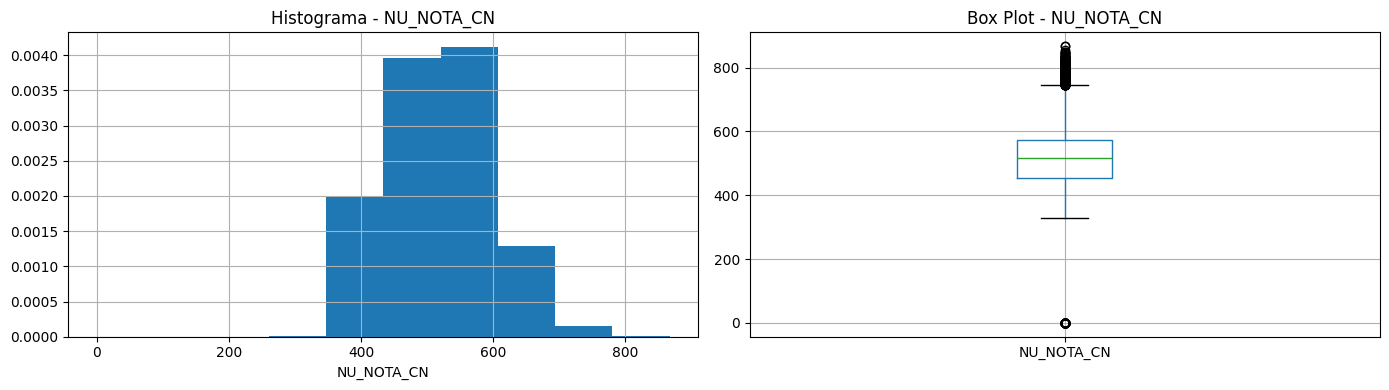

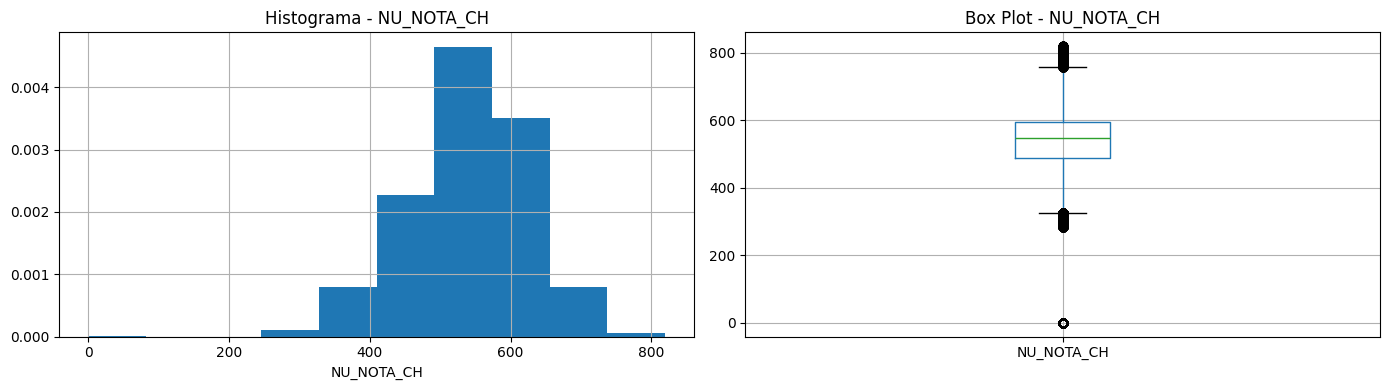

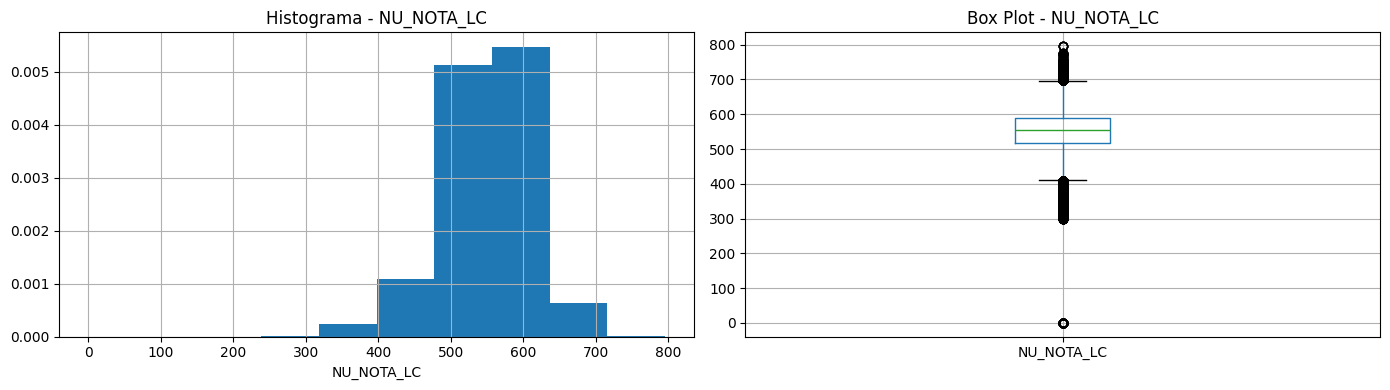

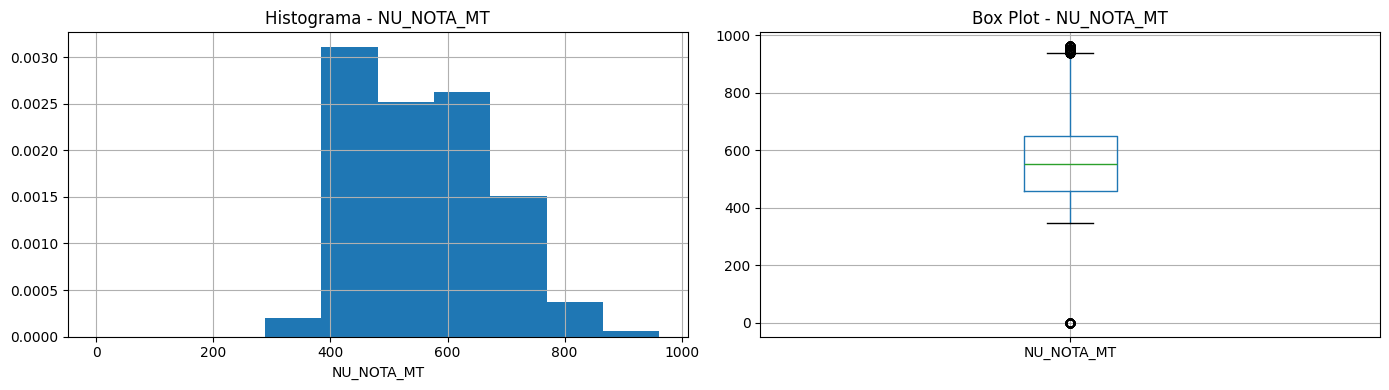

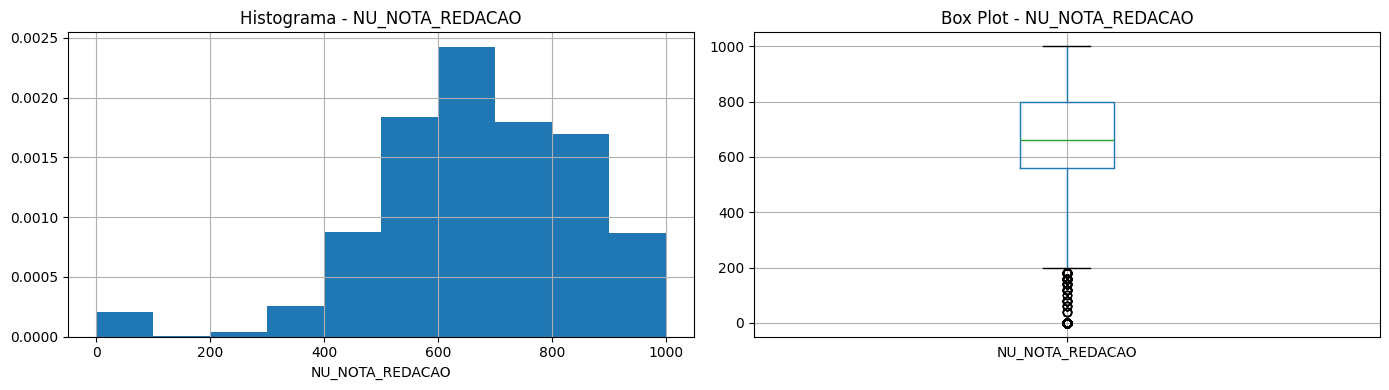

In [707]:
analise_notas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']

for col in analise_notas:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    df_resultado[col].hist(ax=ax1, density=True)
    ax1.set_title(f'Histograma - {col}')
    ax1.set_xlabel(col)
    
    df_resultado.boxplot(column=col, ax=ax2)
    ax2.set_title(f'Box Plot - {col}')
    
    plt.tight_layout()
    plt.show()

In [708]:
for col in analise_notas:
    Q1 = df_resultado[col].quantile(0.25)
    Q3 = df_resultado[col].quantile(0.75)
    IQR = Q3 - Q1
    df_resultado = df_resultado[(df_resultado[col] >= Q1 - 1.5*IQR) & (df_resultado[col] <= Q3 + 1.5*IQR)]

print(((df_resultado.shape[0] - df_resultado.shape[0]) / df_resultado.shape[0]) * 100)

0.0


In [709]:
df_resultado.head()

,NO_MUNICIPIO_PROVA,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
3,OSASCO,550.7,553.8,605.9,629.1,740.0
9,INDAIATUBA,599.5,640.3,597.6,665.3,760.0
34,GUAÍRA,412.2,507.7,475.3,382.4,520.0
36,ITAPECERICA DA SERRA,447.4,591.2,586.9,538.3,480.0
39,OSASCO,408.1,547.7,518.9,591.4,840.0


In [710]:
df_resultado = df_resultado.groupby('NO_MUNICIPIO_PROVA').agg(
    NU_NOTA_CN_MEDIA=('NU_NOTA_CN', 'mean'),
    NU_NOTA_CH_MEDIA=('NU_NOTA_CH', 'mean'),
    NU_NOTA_LC_MEDIA=('NU_NOTA_LC', 'mean'),
    NU_NOTA_MT_MEDIA=('NU_NOTA_MT', 'mean'),
    NU_NOTA_REDACAO_MEDIA=('NU_NOTA_REDACAO', 'mean')
).reset_index()

In [711]:
df_clustering = df_resultado.merge(
    df_municipio,
    on='NO_MUNICIPIO_PROVA',
    how='left'
)

In [712]:
df_clustering.isnull().sum()

NO_MUNICIPIO_PROVA               0
NU_NOTA_CN_MEDIA                 0
NU_NOTA_CH_MEDIA                 0
NU_NOTA_LC_MEDIA                 0
NU_NOTA_MT_MEDIA                 0
NU_NOTA_REDACAO_MEDIA            0
RENDA_FAMILIAR_SM_LOG_MEDIANA    0
RENDA_FAMILIAR_SM_MEDIA          0
REGIAO                           0
dtype: int64

In [713]:
df_clustering.head()

,NO_MUNICIPIO_PROVA,NU_NOTA_CN_MEDIA,NU_NOTA_CH_MEDIA,NU_NOTA_LC_MEDIA,NU_NOTA_MT_MEDIA,NU_NOTA_REDACAO_MEDIA,RENDA_FAMILIAR_SM_LOG_MEDIANA,RENDA_FAMILIAR_SM_MEDIA,REGIAO
0,ADAMANTINA,525.810123,554.820000,557.684444,583.616296,695.506173,1.098612,2.752041,INTERIOR
1,AGUDOS,520.218269,540.266346,551.470513,568.333333,689.871795,1.252763,2.883191,INTERIOR
2,AMERICANA,533.845202,558.039175,560.798216,590.087470,704.480571,1.386294,3.621081,INTERIOR
3,AMPARO,531.318845,552.114015,559.059280,588.289583,686.837121,1.252763,2.927684,INTERIOR
4,ANDRADINA,502.544260,524.655960,541.908609,549.461258,665.651214,1.098612,2.593284,INTERIOR


In [714]:
X_scaled = df_clustering.copy()

X_scaled = X_scaled.drop(columns=['NO_MUNICIPIO_PROVA', 'RENDA_FAMILIAR_SM_MEDIA'])
df_clustering = df_clustering.drop(columns=['RENDA_FAMILIAR_SM_LOG_MEDIANA'])

col_scatter = ['NU_NOTA_CN_MEDIA', 'NU_NOTA_CH_MEDIA', 'NU_NOTA_LC_MEDIA', 'NU_NOTA_MT_MEDIA', 'NU_NOTA_REDACAO_MEDIA', 'RENDA_FAMILIAR_SM_LOG_MEDIANA']
scaler = StandardScaler()
X_scaled[col_scatter] = scaler.fit_transform(X_scaled[col_scatter])


In [715]:
X_scaled = pd.get_dummies(X_scaled, columns=['REGIAO'], dtype='int8')

In [716]:
X_scaled.head()

,NU_NOTA_CN_MEDIA,NU_NOTA_CH_MEDIA,NU_NOTA_LC_MEDIA,NU_NOTA_MT_MEDIA,NU_NOTA_REDACAO_MEDIA,RENDA_FAMILIAR_SM_LOG_MEDIANA,REGIAO_CAPITAL,REGIAO_INTERIOR,REGIAO_LITORAL
0,1.022390,1.396181,1.042146,1.283894,0.920630,0.029932,0,1,0
1,0.645105,0.251115,0.302612,0.606230,0.723615,1.275477,0,1,0
2,1.564521,1.649462,1.412722,1.570834,1.234435,2.354417,0,1,0
3,1.394066,1.183277,1.205768,1.491113,0.617502,1.275477,0,1,0
4,-0.547368,-0.977093,-0.835371,-0.230580,-0.123298,0.029932,0,1,0


In [ ]:
caminho_tratado = OUTDIR / "ANALISE_NOTAS_ENEM_MUNICIPIOS_SP_TRATADO.csv"
df_clustering.to_csv(caminho_tratado, index=False)

caminho_modelo = OUTDIR / "ANALISE_NOTAS_ENEM_MUNICIPIOS_SP_MODELO.csv"
X_scaled.to_csv(caminho_modelo, index=False)